# 01 - Exploratory Data Analysis

Explores the synthetic complaint dataset generated by `src/ingestion/generators.py`.

> All data here is synthetic demo data.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from src.config import settings

df = pd.read_csv(settings.path('paths.complaints_csv'))
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.shape

(10000, 18)

In [2]:
df.head()

,complaint_id,timestamp,source,complaint_text,category,subcategory,sentiment,emotion,severity,product,region,amount,order_id,customer_id,platform,resolution_status,is_synthetic,injected_incident
0,CMP-000001,2024-01-01 00:40:28,email,"Dear support, My order ORD56855361 from QuickP...",Delivery,late delivery,Neutral,Angry,LOW,CloudStore Subscription,East India,1308.87,ORD60894256,CUST155943,Web,resolved,True,NaN
1,CMP-000002,2024-01-01 01:24:05,email,Order ORD84890157 shows payment pending even t...,Payment,payment pending,Negative,Disappointed,MEDIUM,CloudStore Subscription,North India,4759.47,ORD06626885,CUST538542,Web,in_progress,True,NaN
2,CMP-000003,2024-01-01 04:06:41,support_ticket,"Hello, It would be great if MegaMart Online ad...",Other,feature request,Negative,Satisfied,MEDIUM,QuickPay,West India,807.08,ORD88300398,CUST920114,Web,in_progress,True,NaN
3,CMP-000004,2024-01-01 05:02:19,app_review,"Hey, I never got my package for order ORD00373...",Delivery,missing package,Negative,Angry,MEDIUM,CloudStore Subscription,West India,257.61,ORD46193403,CUST798734,iOS,in_progress,True,NaN
4,CMP-000005,2024-01-01 05:31:38,social_media,I only received a partial refund of part of Rs...,Refund,partial refund,Neutral,Disappointed,LOW,InstaDeliver,South India,3280.75,ORD61962703,CUST491182,Web,resolved,True,NaN


In [3]:
df['category'].value_counts()

category
Payment             1972
Delivery            1536
Technical Issue     1456
Refund              1234
Account              942
Product Quality      862
Customer Service     773
Subscription         611
Fraud                310
Other                304
Name: count, dtype: int64

2026-08-31 04:04:01,404 | INFO     | matplotlib.font_manager | Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)


2026-08-31 04:04:01,658 | INFO     | matplotlib.font_manager | generated new fontManager


<Axes: title={'center': 'Category distribution (class imbalance)'}, xlabel='category'>

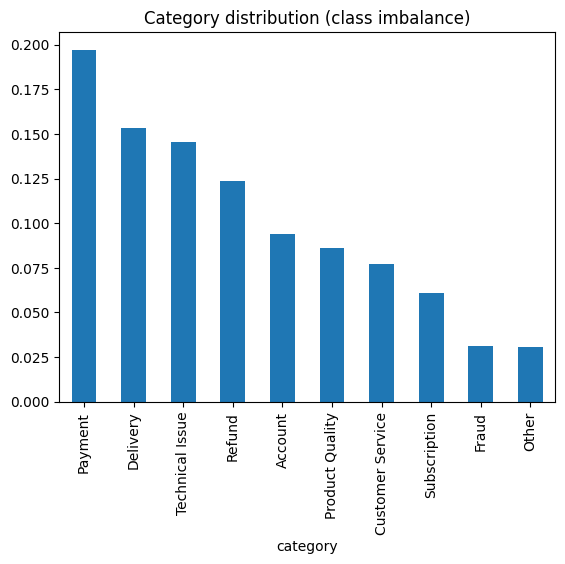

In [4]:
df['category'].value_counts(normalize=True).plot(kind='bar', title='Category distribution (class imbalance)')

<Axes: title={'center': 'Daily complaint volume (note the two injected incident spikes)'}, xlabel='timestamp'>

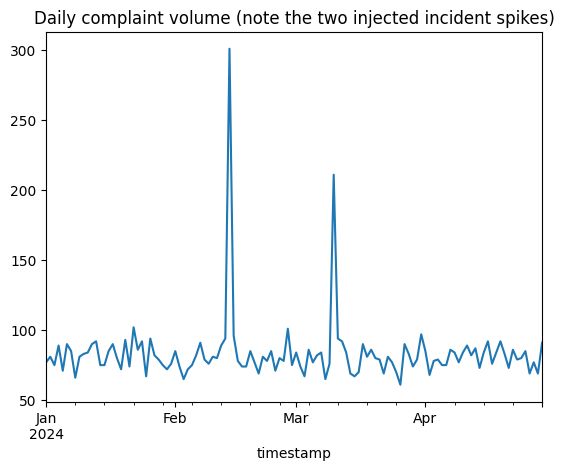

In [5]:
df.set_index('timestamp').resample('D').size().plot(title='Daily complaint volume (note the two injected incident spikes)')

In [6]:
df['sentiment'].value_counts(normalize=True)

sentiment
Negative    0.6982
Neutral     0.2197
Positive    0.0821
Name: proportion, dtype: float64

In [7]:
df.groupby('source').size()

source
app_review         1698
call_transcript    1724
chat               1621
email              1676
social_media       1679
support_ticket     1602
dtype: int64